Bank Loan Dataset:
   Age  Monthly_Income  Credit_Score  Employed  Existing_Loan  Loan_Approved
0   22           18000           450         0              1              0
1   25           22000           480         0              1              0
2   28           28000           520         1              1              0
3   30           35000           580         1              1              0
4   32           42000           620         1              0              1

Actual Loan Approvals:    [1 1 1 1 0 1 1 0 1]
Predicted Loan Approvals: [1 0 1 1 0 1 1 0 1]

Accuracy: 88.89%

Classification Report:
              precision    recall  f1-score   support

Rejected (0)       0.67      1.00      0.80         2
Approved (1)       1.00      0.86      0.92         7

    accuracy                           0.89         9
   macro avg       0.83      0.93      0.86         9
weighted avg       0.93      0.89      0.90         9

Confusion Matrix:
[[2 0]
 [1 6]]


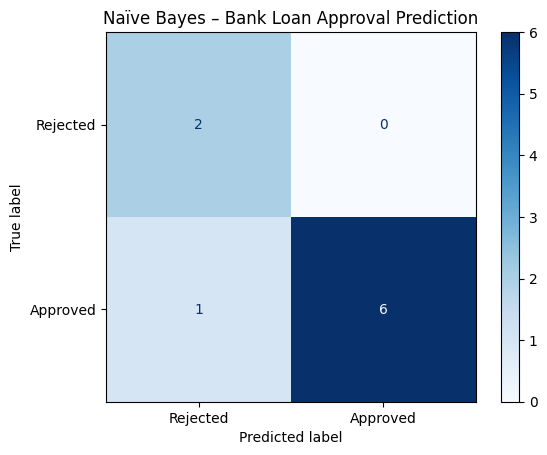

In [1]:
# Step 1: Import required libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# Step 2: Create a sample bank loan dataset
data = {
    "Age": [
        22, 25, 28, 30, 32, 35, 38, 40, 42, 45,
        48, 50, 52, 55, 27, 29, 33, 36, 39, 44,
        46, 49, 31, 34, 41, 43, 47, 51, 54, 37
    ],

    "Monthly_Income": [
        18000, 22000, 28000, 35000, 42000, 50000, 55000, 60000, 65000, 70000,
        75000, 80000, 85000, 90000, 25000, 30000, 40000, 48000, 52000, 68000,
        72000, 78000, 32000, 45000, 58000, 62000, 74000, 82000, 88000, 50000
    ],

    "Credit_Score": [
        450, 480, 520, 580, 620, 700, 720, 750, 780, 800,
        810, 830, 840, 850, 500, 540, 610, 680, 710, 790,
        805, 820, 560, 650, 740, 760, 815, 835, 845, 690
    ],

    # 1 = Employed, 0 = Unemployed
    "Employed": [
        0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
        1, 1, 0, 1, 1, 1, 1, 1, 1, 1
    ],

    # 1 = Already has another loan, 0 = No existing loan
    "Existing_Loan": [
        1, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 0, 0, 0, 1, 1, 0, 0, 1, 0,
        0, 1, 1, 0, 0, 1, 0, 0, 0, 1
    ],

    # Output: 1 = Approved, 0 = Rejected
    "Loan_Approved": [
        0, 0, 0, 0, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 0, 0, 1, 1, 1, 1,
        1, 1, 0, 1, 1, 1, 1, 1, 1, 0
    ]
}

df = pd.DataFrame(data)

print("Bank Loan Dataset:")
print(df.head())

# Step 3: Separate input features (X) and target variable (y)
X = df.drop("Loan_Approved", axis=1)
y = df["Loan_Approved"]

# Step 4: Split data into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Step 5: Initialize and train the Naïve Bayes Classifier
model = GaussianNB()
model.fit(X_train, y_train)

# Step 6: Make predictions on the test dataset
y_pred = model.predict(X_test)

# Step 7: Print prediction results and model accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\nActual Loan Approvals:   ", y_test.to_numpy())
print("Predicted Loan Approvals:", y_pred)
print(f"\nAccuracy: {accuracy * 100:.2f}%")

# Step 8: Print Classification Report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Rejected (0)", "Approved (1)"],
        zero_division=0
    )
)

# Step 9: Compute and Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Rejected", "Approved"]
)

display.plot(cmap="Blues")
plt.title("Naïve Bayes – Bank Loan Approval Prediction")
plt.show()